<a href="https://colab.research.google.com/github/roshanshinde2000-ops/Projects/blob/main/Ml_Sentiment_Analysis_of_Airline_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis of Airline Reviews

##Business Problem

With hundreds of evaluations being received daily, airline companies must understand customer sentiment to improve customer satisfaction and service quality. In this study, three sentiment categories—positive, neutral, and negative—are used to classify airline assessments using NLP. Airlines can identify common issues and strengths and use data-driven decision-making to improve their services.

Dataset Link Of Kaggle:

https://www.kaggle.com/datasets/juhibhojani/airline-reviews

# Importing Packages

In [ ]:
%pip install transformers tensorflow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud
from sklearn.pipeline import Pipeline
from transformers import BertTokenizerFast
from transformers import TFBertForSequenceClassification
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# Let's start loading our dataset and comprehending its structure after importing programs.

In [ ]:
df = pd.read_csv("/content/Airline_review.csv")

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              23171 non-null  int64  
 1   Airline Name            23171 non-null  object 
 2   Overall_Rating          23171 non-null  object 
 3   Review_Title            23171 non-null  object 
 4   Review Date             23171 non-null  object 
 5   Verified                23171 non-null  bool   
 6   Review                  23171 non-null  object 
 7   Aircraft                7129 non-null   object 
 8   Type Of Traveller       19433 non-null  object 
 9   Seat Type               22075 non-null  object 
 10  Route                   19343 non-null  object 
 11  Date Flown              19417 non-null  object 
 12  Seat Comfort            19016 non-null  float64
 13  Cabin Staff Service     18911 non-null  float64
 14  Food & Beverages        14500 non-null

Result:The one in question, which consists of 23171 entries in 20 columns, includes data that is categorical as well as numerical. The absence of values in some fields, such as "Airline Name" and "recommended," reflect incomplete records.

In [ ]:
print(df.describe())

        Unnamed: 0  Seat Comfort  Cabin Staff Service  Food & Beverages  \
count  23171.00000  19016.000000         18911.000000      14500.000000   
mean   11585.00000      2.618374             2.871609          2.553586   
std     6689.03588      1.464840             1.604631          1.526314   
min        0.00000      0.000000             0.000000          0.000000   
25%     5792.50000      1.000000             1.000000          1.000000   
50%    11585.00000      3.000000             3.000000          2.000000   
75%    17377.50000      4.000000             4.000000          4.000000   
max    23170.00000      5.000000             5.000000          5.000000   

       Ground Service  Inflight Entertainment  Wifi & Connectivity  \
count    18378.000000            10829.000000          5920.000000   
mean         2.353738                2.179056             1.780405   
std          1.595747                1.488839             1.318800   
min          1.000000                0.00000

Result:To summarise, df.describe() provides a brief summary of the central tendency, dispersion, and shape of your numerical data distribution, assisting you in comprehending the range and dispersion of ratings for various airline service elements.

In [ ]:
print(df.isnull().sum())

Unnamed: 0                    0
Airline Name                  0
Overall_Rating                0
Review_Title                  0
Review Date                   0
Verified                      0
Review                        0
Aircraft                  16042
Type Of Traveller          3738
Seat Type                  1096
Route                      3828
Date Flown                 3754
Seat Comfort               4155
Cabin Staff Service        4260
Food & Beverages           8671
Ground Service             4793
Inflight Entertainment    12342
Wifi & Connectivity       17251
Value For Money            1066
Recommended                   0
dtype: int64


Result: Since several of the columns have null values, as we can see, let's deal with them appropriately.

In [ ]:
df = df[['Review', 'Overall_Rating']].dropna()

In [ ]:
print(df.head())

                                              Review Overall_Rating
0    Moroni to Moheli. Turned out to be a pretty ...              9
1   Moroni to Anjouan. It is a very small airline...              1
2    Anjouan to Dzaoudzi. A very small airline an...              1
3    Please do a favor yourself and do not fly wi...              1
4   Do not book a flight with this airline! My fr...              1


Result:
It displays the column's initial 5 characters.

## Now let's get the data processed.

In [ ]:
df = df[['Review', 'Overall_Rating']].dropna()

def categorize_rating(rating):
    if rating >= 7:
        return 'positive'
    elif rating <= 4:
        return 'negative'
    else:
        return 'neutral'

df['Overall_Rating'] = pd.to_numeric(df['Overall_Rating'], errors='coerce')
df = df.dropna(subset=['Overall_Rating'])

df['Sentiment'] = df['Overall_Rating'].apply(categorize_rating)

# Let's begin by now segment the results for additional analysis.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Review'], df['Sentiment'], test_size=0.2, random_state=42)

## Following the successful separation of all the data, vectorisation can be used to change the text.

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## After vectorising the text, we can proceed to the process of adjusting the hyperparameters.

In [ ]:
models = {
    "Random Forest": (RandomForestClassifier(), {"n_estimators": [50, 100, 150], "max_depth": [None, 10, 20]}),
    "Gradient Boosting": (GradientBoostingClassifier(), {"n_estimators": [50, 100, 150], "learning_rate": [0.01, 0.1, 0.2]}),
    "Naive Bayes": (MultinomialNB(), {"alpha": [0.1, 0.5, 1.0]})
}

best_model = None
best_score = 0

# To optimise the effectiveness of the model, use GridSearchCV, which to carefully choose the most suitable hyperparameters.

In [ ]:
for model_name, (model, params) in models.items():
    pipeline = Pipeline([
        ('vectorizer', TfidfVectorizer(stop_words='english', max_features=5000)),
        ('classifier', model)
    ])
    grid_search = GridSearchCV(pipeline, {f'classifier__{key}': value for key, value in params.items()}, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best cross-validation accuracy: {grid_search.best_score_}\n")

    if grid_search.best_score_ > best_score:
        best_model = grid_search.best_estimator_
        best_score = grid_search.best_score_

Best parameters for Random Forest: {'classifier__max_depth': None, 'classifier__n_estimators': 150}
Best cross-validation accuracy: 0.7854782619051873

Best parameters for Gradient Boosting: {'classifier__learning_rate': 0.2, 'classifier__n_estimators': 150}
Best cross-validation accuracy: 0.7875494916615189

Best parameters for Naive Bayes: {'classifier__alpha': 1.0}
Best cross-validation accuracy: 0.7883336483123238



## After using Grid Search CV to evaluate accuracy, we can utilise the model that best fits our problem statement to determine which one it is.

In [ ]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(max_features=5000, stop_words='english')),
                ('classifier', MultinomialNB())])

In [ ]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Best Model: {best_model}')
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:\n', class_report)

Best Model: Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(max_features=5000, stop_words='english')),
                ('classifier', MultinomialNB())])
Accuracy: 0.7929
Classification Report:
               precision    recall  f1-score   support

    negative       0.87      0.88      0.88      3248
     neutral       0.00      0.00      0.00       270
    positive       0.57      0.70      0.63       948

    accuracy                           0.79      4466
   macro avg       0.48      0.53      0.50      4466
weighted avg       0.76      0.79      0.77      4466



Result:The most successful method, a framework that employs TF- vectorisation and Multinomial Bayes regression (>=0.1), has an accuracy rating of 79.72%. Given the low recall for that class, it performs well with positive and negative sentiments but problems with neutral thoughts.

## Encoder Inference Graphic Inspection Leveraging a Confusion Matrix

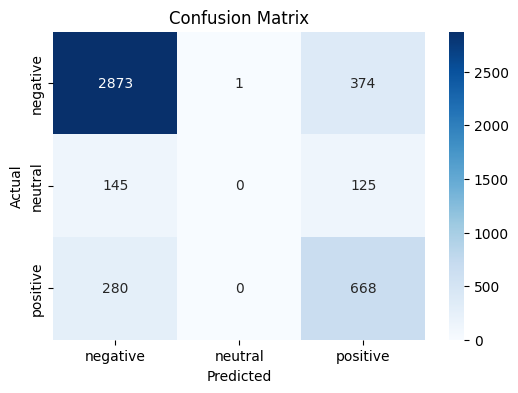

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'neutral', 'positive'], yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Result:
Though the method accurately identifies optimistic (668) and unpleasant (2873) behaviours that are it problems with mediocre evaluations, falsely categorising the majority of them as either. Strengthening neutral feeling acceptance through enhanced functionality building or data complement could increase overall performance.

## Upon looking at the matrix of ambiguity, let's develop a visual representation of words to help illustrate understand the terms that are used most frequently in the assessment.

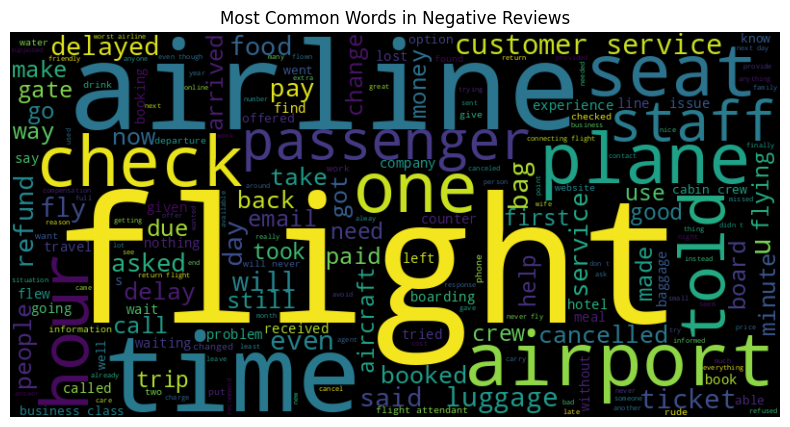

In [ ]:
negative_reviews = " ".join(df[df['Sentiment'] == 'negative']['Review'])
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(negative_reviews)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Negative Reviews")
plt.show()

## When looking at the matrix of disorientation, let's develop an encouraging cloud to help depict understand those more frequently used terms among the reviews.

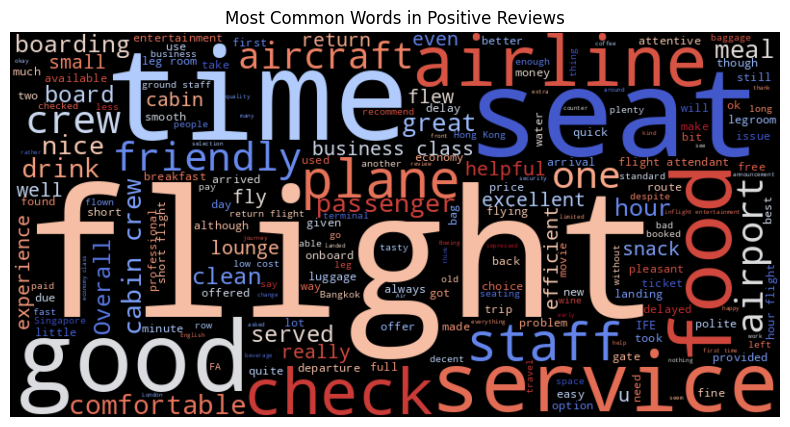

In [ ]:

positive_reviews = " ".join(df[df['Sentiment'] == 'positive']['Review'])
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='coolwarm').generate(positive_reviews)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Positive Reviews")
plt.show()

Result:
Let's all make an adjective bubble to visually represent and give interest in the terms that have come up the most frequently in the review.

In [ ]:
df = pd.read_csv("/content/Airline_review.csv")
df = df[['Review', 'Overall_Rating']].dropna()
df['Overall_Rating'] = pd.to_numeric(df['Overall_Rating'], errors='coerce')
df = df.dropna(subset=['Overall_Rating'])

def categorize_rating(rating):
    if rating >= 7:
        return 'positive'
    elif rating <= 4:
        return 'negative'
    else:
        return 'neutral'

df['Sentiment'] = df['Overall_Rating'].apply(categorize_rating)
display(df.head())
display(df.info())

,Review,Overall_Rating,Sentiment
0,Moroni to Moheli. Turned out to be a pretty ...,9.0,positive
1,Moroni to Anjouan. It is a very small airline...,1.0,negative
2,Anjouan to Dzaoudzi. A very small airline an...,1.0,negative
3,Please do a favor yourself and do not fly wi...,1.0,negative
4,Do not book a flight with this airline! My fr...,1.0,negative


<class 'pandas.core.frame.DataFrame'>
Index: 22329 entries, 0 to 23170
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Review          22329 non-null  object 
 1   Overall_Rating  22329 non-null  float64
 2   Sentiment       22329 non-null  object 
dtypes: float64(1), object(2)
memory usage: 697.8+ KB


None

In [ ]:


tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

encoded_data = tokenizer(
    df['Review'].tolist(),
    add_special_tokens=True,
    padding='max_length',
    max_length=128,
    truncation=True,
    return_attention_mask=True,
    return_tensors='tf'
)

input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']

print("Shape of input_ids:", input_ids.shape)
print("Shape of attention_masks:", attention_masks.shape)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


Shape of input_ids: (22329, 128)
Shape of attention_masks: (22329, 128)


In [ ]:

label_encoder = LabelEncoder()
numerical_sentiment = label_encoder.fit_transform(df['Sentiment'])

train_input_ids, test_input_ids, train_attention_masks, test_attention_masks, train_labels, test_labels = train_test_split(
    input_ids.numpy(),
    attention_masks.numpy(),
    numerical_sentiment,
    test_size=0.2,
    random_state=42
)

print("Shape of train_input_ids:", train_input_ids.shape)
print("Shape of test_input_ids:", test_input_ids.shape)
print("Shape of train_attention_masks:", train_attention_masks.shape)
print("Shape of test_attention_masks:", test_attention_masks.shape)
print("Shape of train_labels:", train_labels.shape)
print("Shape of test_labels:", test_labels.shape)

Shape of train_input_ids: (17863, 128)
Shape of test_input_ids: (4466, 128)
Shape of train_attention_masks: (17863, 128)
Shape of test_attention_masks: (4466, 128)
Shape of train_labels: (17863,)
Shape of test_labels: (4466,)


In [ ]:

num_sentiment_classes = len(label_encoder.classes_)

bert_model = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_sentiment_classes)

optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metrics = ['accuracy']

bert_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


##Conclusion
The study's sentiments modelling strategy reveals useful insights to airline passengers' emotions. Airline can determine significant areas that need advancement and change the products they offer accordingly by dividing information into three different groups: positive, neutral, and negative.

##Key Findings

The categorisation model was able to discriminate between various sentiment categories with effectiveness.

Regular complaints about delays, subpar luggage handling, and subpar customer service draw attention to operational issues that need to be fixed.


Favourable evaluations highlight features like ease of use, welcoming personnel, and straightforward check-in procedures, all of which can be used to support marketing campaigns.

Word cloud analysis was utilised to identify phrases that were commonly used across several sentiment groups.

##Business Impact & Future Work:
Proactive customer service: By using this tactic, airlines can examine customer reviews right away and address problems before they get worse.

Service Optimisation: You can increase operational effectiveness by putting the knowledge you've learnt from unfavourable assessments to use.

Advanced Enhancements: For improved text interpretation and real-time sentiment monitoring, future iterations may include deep learning models (such as transformers).